# Testing JSBSim computations of rotations against an exact solution

This notebook aims to assess the fidelity of JSBSim with regard to the computation of a vehicle rotation. For that purpose, in this notebok, the exact solution of the free rigid body rotation of a top is computed by JSBSim and compared to the exact solution.

The exact solution is evaluated using the program `free_rigid_body_rotations.c` in the folder `data`. The program comes from the paper *Numerical implementation of the exact rigid dynamics of free rigid bodies*, van Zon R., Schofield J., 2006.

For this evaluation, we are assuming that the vehicle is a top which principal inertias are $I_{xx}=10$, $I_{yy}=20$ and $I_{zz}=26$. The initial value for the rotation rates are $\omega_x=1$, $\omega_y=15$ and $\omega_z=1$. No torques are applied, the movement is one of a free rigid body. These assumptions are the same as van Zon and Schofield's paper.

The exact solutions of this problem are [Jacobi elliptic functions](https://en.wikipedia.org/wiki/Jacobi_elliptic_functions) which are very smooth and on which the classical algorithms (Euler, Adams-Bashforth) are expected to perform well.

Please note that:
1. The values are hardcoded in the program `data/free_rigid_body_rotations.c`. For different values to be tested, the code in `free_rigid_body_rotations.c` should be modified and re-run to update the CSV file `data/top.csv`. If the inertias are modified in `data/free_rigid_body_rotations.c`, make sure that they are modified accordingly in `data/top.xml`.
2. The Earth rotation rate is forced to zero in the model `top.xml`
3. The rotation rate $\omega_y=15\text{ rad/s}$ is unrealistic for most aircraft applications, including fighter jets and aerobatics (although [some claim that the A4 Skyhawk can reach 720 deg/s](https://seanmcleod70.github.io/FlightDynamicsCalcs/A4SkyhawkRollPerformance.html) e.g. 12.5 rad/s).

## Setting up the simulation script

In [1]:
# Confirm that JSBSim is installed. If not and running on Google Colab
# then install JSBSim into the Google Colab instance.

import os

try:
  import jsbsim
  print('JSBSim is installed')
  print(f'Current working directory: {os.getcwd()}')
except ImportError:
  import sys
  if 'google.colab' in sys.modules:
      print('Installing JSBSim...')
      !pip install jsbsim
  else:
    sys.path.append('../../../build/Debug/tests')
    import jsbsim

### Integration schemes enumeration

In this cell, we define an enumeration for the various ODE integration methods available in JSBSim. The list `method_names` will serve to display the integration scheme names in plain English in the plot legends.

In [2]:
import enum

class ODE_methods(enum.IntEnum):
    NONE = 0
    EULER = 1
    TRAPEZOIDAL = 2
    ADAMS_BASHFORTH2 = 3
    ADAMS_BASHFORTH3 = 4
    ADAMS_BASHFORTH4 = 5
    BUSS1 = 6
    BUSS2 = 7
    LOCAL_LINEARIZATION = 8
    ADAMS_BASHFORTH5 = 9

method_names = ["None", "Euler", "Trapezoidal", "Adams-BashForth 2", "Adams-BashForth 3",
                "Adams-BashForth 4", "Buss 1", "Buss 2", "Local linearization",
                "Adams-BashForth 5"]

### Data structure for simulation results

We define a `SimulationResults` dataclass to store the output of the multiple simulations. This allows for easy sharing of data between the computation function and the plotting functions.

The rotation rates $p$, $q$ and $r$ are expressed in the body frame and are measured in rad/s.

Roll, pitch and yaw measure the aircraft attitude with respect to the horizontal ground, more precisely in the NED (North, East, Down) frame.
* Roll is the angle around the body frame X axis and is in the range $[-\pi,\pi]$. Positive angles are roll to the right.
* Pitch is the angle around the body frame Y axis and is in the range $[-\frac{\pi}{2},\frac{\pi}{2}]$. Positive angles are pitch up.
* Yaw is pilot's heading. It is measured clockwise looking down in the range $[0,2\pi]$ with 0 being the geometric North.

In [3]:
from dataclasses import dataclass

@dataclass
class SimulationResults:
    methods: tuple
    times: np.ndarray
    p: np.ndarray
    q: np.ndarray
    r: np.ndarray
    roll: np.ndarray
    pitch: np.ndarray
    yaw: np.ndarray

### Exact solution preparation

The exact solution has been precomputed using the C program `data/free_rigid_body_rotations.c` and stored in the CSV file `data/top.csv`. The program from van Zon and Schofield compute the rotation rates $p$, $q$ and $r$ as well as a matrix $A$. In their paper, $A$ is the transformation matrix from the *lab frame* to the body frame. In JSBSim parlance, $A$ is `Ti2b`.

We load the exact solution from `data/top.csv` and compute the Euler angles from  the matrix $A$ to serve as the reference for our integration methods.

In [4]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

# Load the exact resolution of the free rigid body rotation
exact = pd.read_csv('data/top.csv', header=None, sep='\\s+')

nvalues = len(exact.iloc[:,0])
freq_exact = int(nvalues / exact.iloc[-1,0])
t_final = nvalues / freq_exact

# Compute the Euler angles of the exact solution
# - Columns 4 to 12 contain the Ti2b matrix values
# - Ti2b is the transform matrix from inertial frame to the body frame
Ti2b_data = exact.iloc[:, 4:13].values # Extract the data of matrices (one per time step)
Ti2b = Ti2b_data.reshape(-1, 3, 3)
rotations = R.from_matrix(Ti2b)
# JSBSim order for Euler angles is yaw/pitch/roll eg. z/y/x
euler_angles = rotations.as_euler('zyx', degrees=False)
# In JSBSim, Euler angles measure the body attitude with respect to the inertial frame
# so we need to change the sign of the Euler angles from the exact computation.
exact[13] = -euler_angles[:, 2] # Roll
exact[14] = -euler_angles[:, 1] # Pitch
exact[15] = -euler_angles[:, 0] # Yaw
# In JSBSim, yaw measures the heading from 0 (North) to 2pi
exact[15] = exact[15] % (2.0*np.pi)

# Avoid flooding messages
jsbsim.FGJSBBase().debug_lvl = 0  # Disable debug introspection.
jsbsim.get_logger().set_min_level(jsbsim.LogLevel.WARN)  # Ignore info messages

### Helper functions for the tests

#### Simulation function

This function iterates over a list of methods and frequencies, runs the JSBSim simulation for each one, and stores the results in a `SimulationResults` object.

In order to allow the evaluation of a number of parameters, the `methods` is a list of tuples. Each tuple include 3 values:
1. The integration scheme from the `ODE_methods` enumeration for the computation of the Euler angles
1. The integration scheme from the `ODE_methods` enumeration for the computation of the rotation rates
1. The time step frequency i.e. 120Hz is 120 time steps per simulated second.

The function `run_rotations_simulations` launches a simulation for each tuple. The results are returned in a `SimulationResults` data class.

In [5]:
from typing import List, Tuple

def run_rotations_simulations(methods: List[Tuple[ODE_methods, ODE_methods, int]],
                              t_final: float) -> SimulationResults:
    nsteps = max([int(m[2]*t_final) for m in methods])
    n_methods = len(methods)

    results = SimulationResults(
        methods=methods,
        times=np.empty((n_methods, nsteps)),
        p=np.empty((n_methods, nsteps)),
        q=np.empty((n_methods, nsteps)),
        r=np.empty((n_methods, nsteps)),
        roll=np.empty((n_methods, nsteps)),
        pitch=np.empty((n_methods, nsteps)),
        yaw=np.empty((n_methods, nsteps))
    )

    for j, method in enumerate(methods):
        fdm = jsbsim.FGFDMExec(".")
        fdm.set_aircraft_path('data')
        fdm.load_model('top', False)
        fdm.set_dt(1.0/float(method[2]))
        fdm['ic/p-rad_sec'] = 1.0
        fdm['ic/q-rad_sec'] = 15.0
        fdm['ic/r-rad_sec'] = 1.0
        fdm['ic/phi-rad'] = 0.0
        fdm['ic/theta-rad'] = 0.0
        fdm['ic/psi-true-rad'] = 0.0
        fdm['simulation/integrator/position/rotational'] = method[0]
        fdm['simulation/integrator/rate/rotational'] = method[1]
        fdm.run_ic()

        for i in range(nsteps):
            results.times[j, i] = fdm.get_sim_time()
            results.p[j, i] = fdm['velocities/p-rad_sec']
            results.q[j, i] = fdm['velocities/q-rad_sec']
            results.r[j, i] = fdm['velocities/r-rad_sec']
            results.roll[j, i] = fdm['attitude/roll-rad']
            results.pitch[j, i] = fdm['attitude/pitch-rad']
            results.yaw[j, i] = fdm['attitude/psi-rad']
            fdm.run()

    return results

#### Plotting function for rotation rates

This function visualizes the rotation rates $(p, q, r)$ compared to the exact solution.
* The parameter `time_range` gives the x axis range to focus on a specific time range
* The parameter `y_range` gives the y axis range to focus on.
* The parameter `name_col` determines which integration scheme names are displayed in the legend (0: scheme for Euler angles, 1: scheme for rotation rates)
* The parameter `n_points_exact` specifies the number of points from the exact solution to be displayed. This allows to reduce the point density on a plot for better legibility.

In [6]:
import matplotlib.pyplot as plt

def plot_rotation_rates(results: SimulationResults, exact_data, *, time_range=(0, t_final),
                        y_range: Tuple[flot, float] | None = None,
                        name_col=0, n_points_exact:int | None = None) -> None:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    for i in range(len(results.methods)):
        label = f"{method_names[results.methods[i][name_col]]} ({results.methods[i][2]:.0f}Hz)"
        ax1.plot(results.times[i, :], results.p[i, :], label=label)
        ax2.plot(results.times[i, :], results.q[i, :], label=label)
        ax3.plot(results.times[i, :], results.r[i, :], label=label)

    if n_points_exact is None:
        freq = 1
    else:
        time_span = time_range[1] - time_range[0]
        freq = max(1, int(freq_exact * time_span / n_points_exact))

    ax1.plot(exact_data.iloc[::freq, 0], exact_data.iloc[::freq, 1], '+', label='Exact')
    ax2.plot(exact_data.iloc[::freq, 0], exact_data.iloc[::freq, 2], '+', label='Exact')
    ax3.plot(exact_data.iloc[::freq, 0], exact_data.iloc[::freq, 3], '+', label='Exact')

    for ax, title in zip((ax1, ax2, ax3), ('p', 'q', 'r')):
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_xlim(time_range)
        if y_range is not None:
            ax.set_ylim(y_range)
        ax.legend()
        ax.grid()

    ax1.set_ylabel("rad/s")
    plt.show()

#### Plotting function for rotation rate errors

This function calculates and displays the error between the simulated rotation rates and the exact solution reference.

The function parameters are the same as `plot_rotation_rates`.

In [7]:
def plot_rotation_rate_errors(results: SimulationResults, exact_data, *, time_range=(0, t_final),
                            y_range: Tuple[float, float] | None = None, name_col=0) ->  None:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    nvalues = len(exact_data)

    for i in range(len(results.methods)):
        step = int(results.methods[i][2] / freq_exact)
        label = f"{method_names[results.methods[i][name_col]]} ({results.methods[i][2]:.0f}Hz)"

        ax1.plot(exact_data.iloc[:, 0], results.p[i, :step*nvalues:step] - exact_data.iloc[:, 1], label=label)
        ax2.plot(exact_data.iloc[:, 0], results.q[i, :step*nvalues:step] - exact_data.iloc[:, 2], label=label)
        ax3.plot(exact_data.iloc[:, 0], results.r[i, :step*nvalues:step] - exact_data.iloc[:, 3], label=label)

    for ax, title in zip((ax1, ax2, ax3), ("p error", "q error", "r error")):
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_xlim(time_range)
        if y_range is not None:
            ax.set_ylim(y_range)
        ax.legend()
        ax.grid()

    ax1.set_ylabel("rad/s")
    plt.show()

## Rotation Rates

We will start to investigate the computation of the rotation rates. JSBSim computes the rotation rates in the body frame, using the classical Euler formula:

$$J\dfrac{d\omega}{dt}=\sum_i M_i-\omega\times J\omega$$

and using explicit integration schemes such as, for example, the Adams-Bashforth method of the 2nd order

$$\omega(t+h)=\omega(t)+\dfrac{h}{2}\left(3\dfrac{d\omega}{dt}(t)-\dfrac{d\omega}{dt}(t-h)\right)$$

Since no frame transformations are involved, the computation of the rotation rates is independant of the computation of the attitude i.e. of the Euler angles.

### Trapezoidal Method

We will start investigating the *trapezoidal* method that JSBSim provides. This method is not a classical ODE (Ordinary Differential Equations) numerical scheme, it is not listed in the classical textbooks about Numerical Analysis so it seems to be unique to JSBSim. Let's see how it compares to the good old Euler method.

For this first investigation, we will use a time step of 120Hz (i.e. 120 steps par second) which is the default time step for JSBSim. The method of Adams-Bashforth of the 5th order will be used to compute the Euler angles assuming that it gives maximum accuracy.

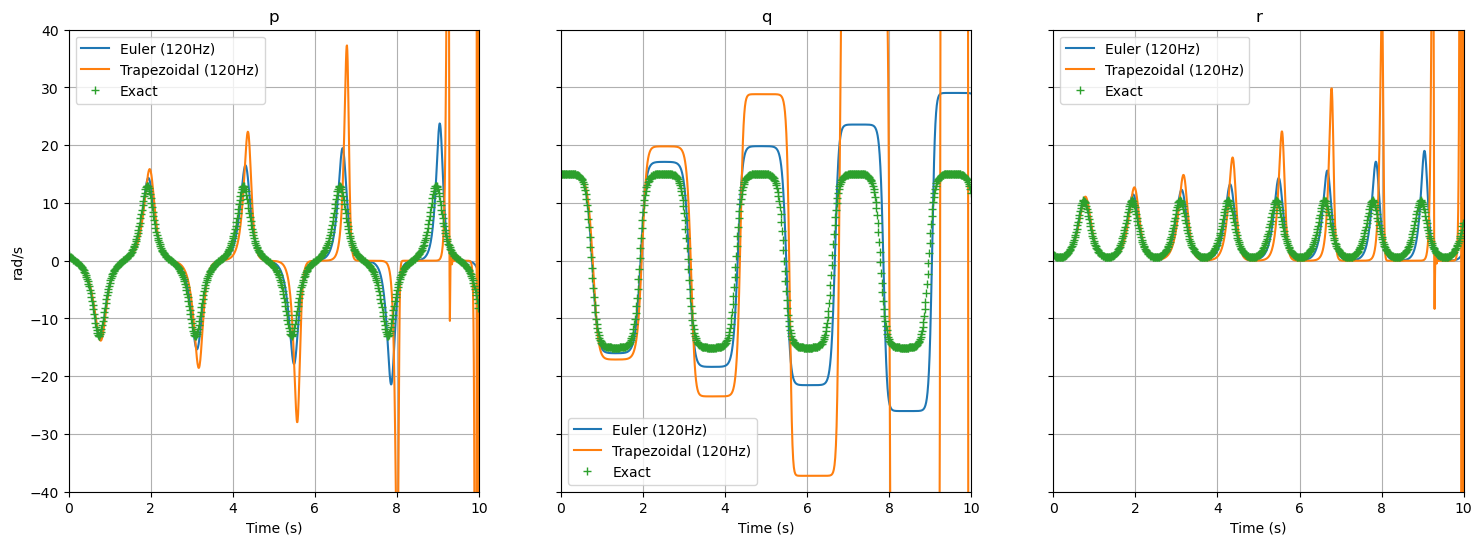

In [8]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.EULER, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.TRAPEZOIDAL, 120))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rates(results, exact, y_range=(-40,40), name_col=1)

The Euler method (blue curve) is unsurprisingly diverging from the exact solution (green crosses) but the trapezoidal method (orange curve) is diverging even faster to the point that it finally diverges to infinity before the 10 seconds simulation mark. This suboptimal performance warrants a formal analysis of the method's consistency order.

#### Consistency Error of the Trapezoidal Method

##### Mathematical Framework

Consider the initial value problem (IVP):

$$\dot{y} = f(t, y), \quad y(t_0) = y_0$$

where $f \in \mathcal{C}^1([t_0, t_0+T] \times \mathbf{R}, \mathbf{R})$. Let $z(t)$ denote the exact solution. For a uniform discretization with step size $h$, we define $t_n = t_0 + nh$. The local truncation error $\tau_{n+1}$ is defined as the difference between the exact solution $z(t_{n+1})$ and the numerical approximation $y_{n+1}$, assuming all prior values are exact (i.e., $y_k = z(t_k)$ for $k \le n$).

##### Error Analysis of the JSBSim Trapezoidal Scheme

The trapezoidal method implemented in JSBSim employs the following explicit update rule:

$$y_{n+1} = y_n + \frac{h}{2} \left( f_n + f_{n-1} \right)$$

Under the assumption that $y_n = z(t_n)$ and $y_{n-1} = z(t_{n-1})$, we expand $z(t_{n+1})$ and $f_{n-1} = z'(t_n - h)$ using Taylor series around $t_n$:

$$z(t_{n+1}) = z(t_n) + h z'(t_n) + \frac{h^2}{2} z''(t_n) + \mathcal{O}(h^3)$$
$$f_{n-1} = z'(t_n) - h z''(t_n) + \mathcal{O}(h^2)$$

Substituting these expressions into the definition of the local truncation error:

$$\tau_{n+1} = z(t_{n+1}) - \left[ z(t_n) + \frac{h}{2}(z'(t_n) + f_{n-1}) \right]$$
$$\tau_{n+1} = \left[ z(t_n) + h z'(t_n) + \frac{h^2}{2} z''(t_n) \right] - \left[ z(t_n) + \frac{h}{2}(2z'(t_n) - h z''(t_n))\right] + \mathcal{O}(h^3)$$
$$\tau_{n+1} = h^2 z''(t_n) + \mathcal{O}(h^3)$$

#### Conclusion

The analysis confirms that the JSBSim trapezoidal method is of first-order accuracy. Notably, its local truncation error is $h^2 z''(t_n)$, which is exactly twice that of the forward Euler method ($\frac{1}{2}h^2 z''(t_n)$). Consequently, the trapezoidal scheme is less accurate than the forward Euler method, explaining its poor numerical stability and rendering it unsuitable for high-fidelity ODE integration.

Below are plotted the errors of the Euler and trapezoidal methods with respect to the exact solution. It is obvious that both methods are performing poorly, with the error of the trapezoidal method being twice the error of the Euler method during the first 3 seconds. After that, the trapezoidal method diverges much faster than Euler.


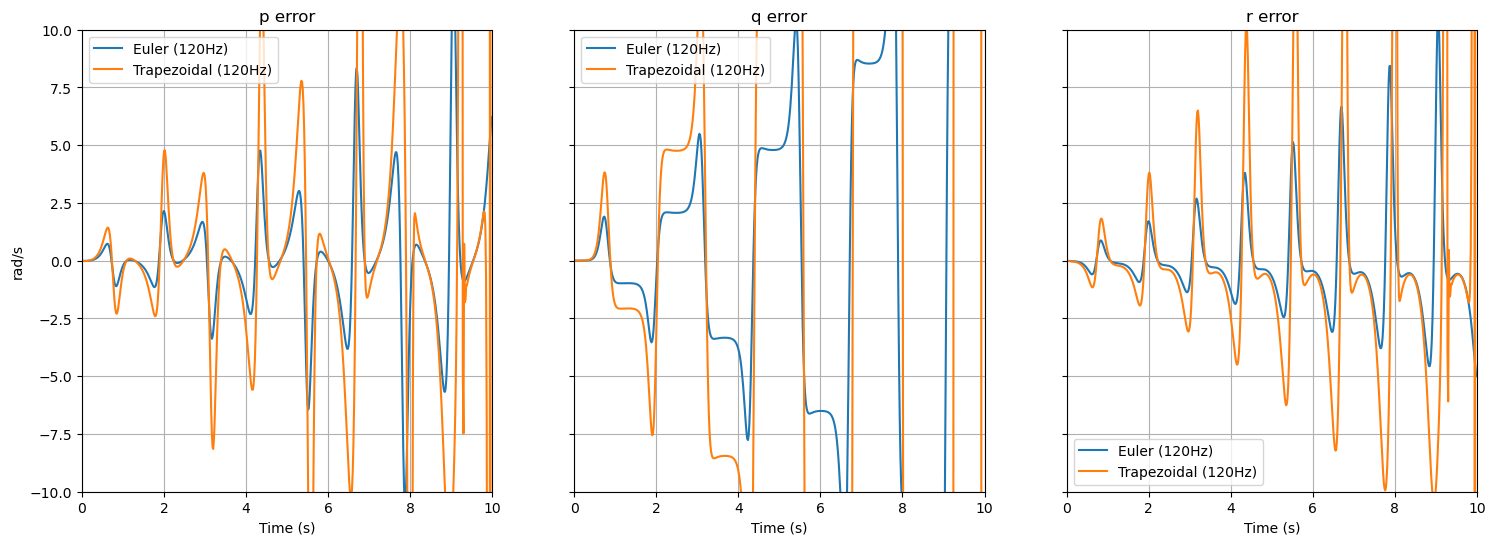

In [9]:
plot_rotation_rate_errors(results, exact, y_range=(-10,10), name_col=1)

### Adams-Bashforth methods

Given that the Euler and trapezoidal methods perform poorly. We will now evaluate how the Adams-Bashforth perform.

JSBSim allows using the Adams-Bashforth schemes of the second to the fifth order so we will test them all and compare their respective performance as well as their accuracy with respect to the exact solution.

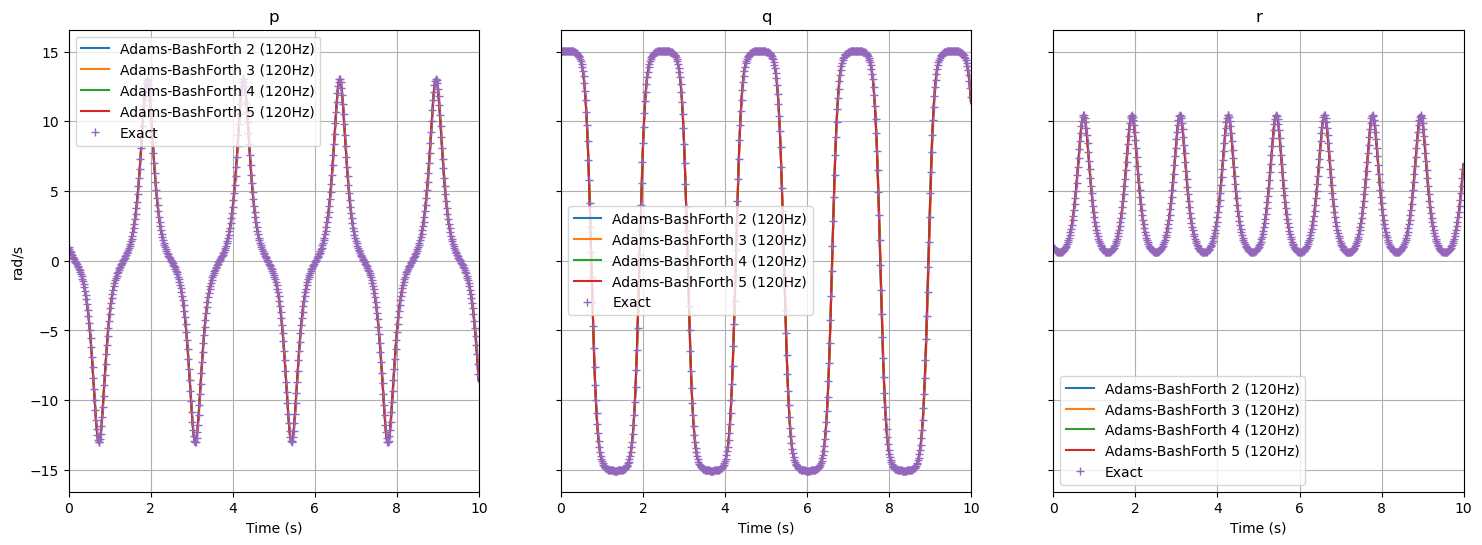

In [10]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH2, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH3, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH4, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rates(results, exact, name_col=1)

The explicit Adams-Bahforth methods bring significant improvements over Euler and the trapezoidal methods. They are performing very well over the 10 simulated seconds with no obvious sign of frequency drift or ampltiude divergence.

Below are the errors between the Adams-Bashforth schemes and the exact solution.

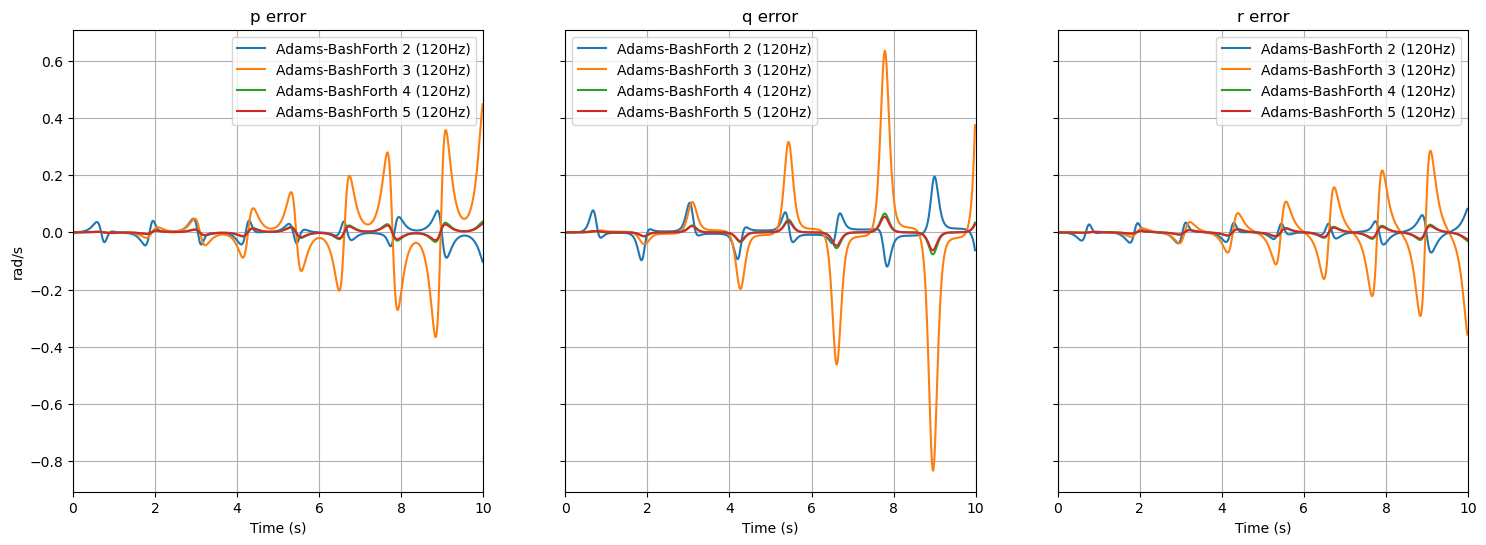

In [11]:
plot_rotation_rate_errors(results, exact, name_col=1)

Unexpectedly the Adams-Bashforth scheme of the 3rd order is performing significantly worse than Adams-Bashforth of the 2nd order. The 4th and 5th order schemes cannot be distinguished but are closer to the exact solution than the 2nd and 3rd order.

In the plots below the step size has been halved. The error has diminished but the hierarchy is not changed: the 3rd order method is still giving the larger errors, followed by 2nd order. There again, the 4th and 5th order cannot be distinguished.

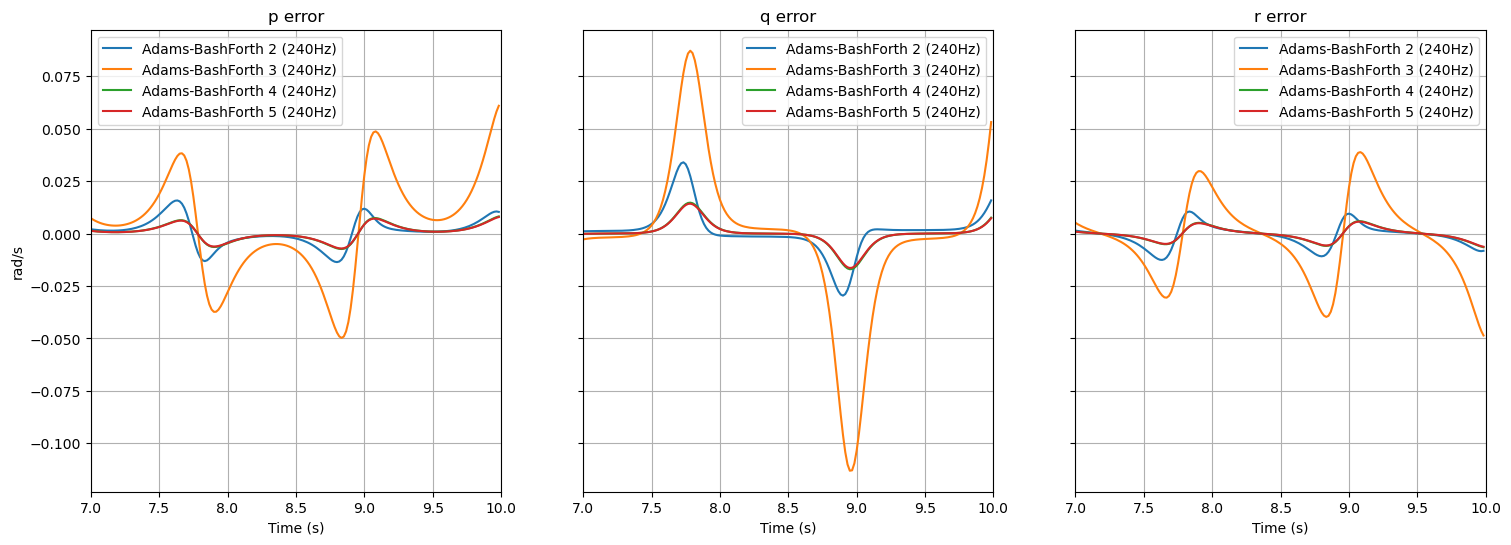

In [12]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH2, 240),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH3, 240),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH4, 240),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 240))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rate_errors(results, exact, time_range=(7, 10),name_col=1)

With a the time step of $\frac{1}{600}$ seconds, the expected hierarchy between the order of the methods is "restored". However the 3rd order method is only slightly better than the 2nd order. Additionally, the 4th and 5th order are giving the same error which tends to indicate that the remaining error is unrelated to the precision of the integration methods.

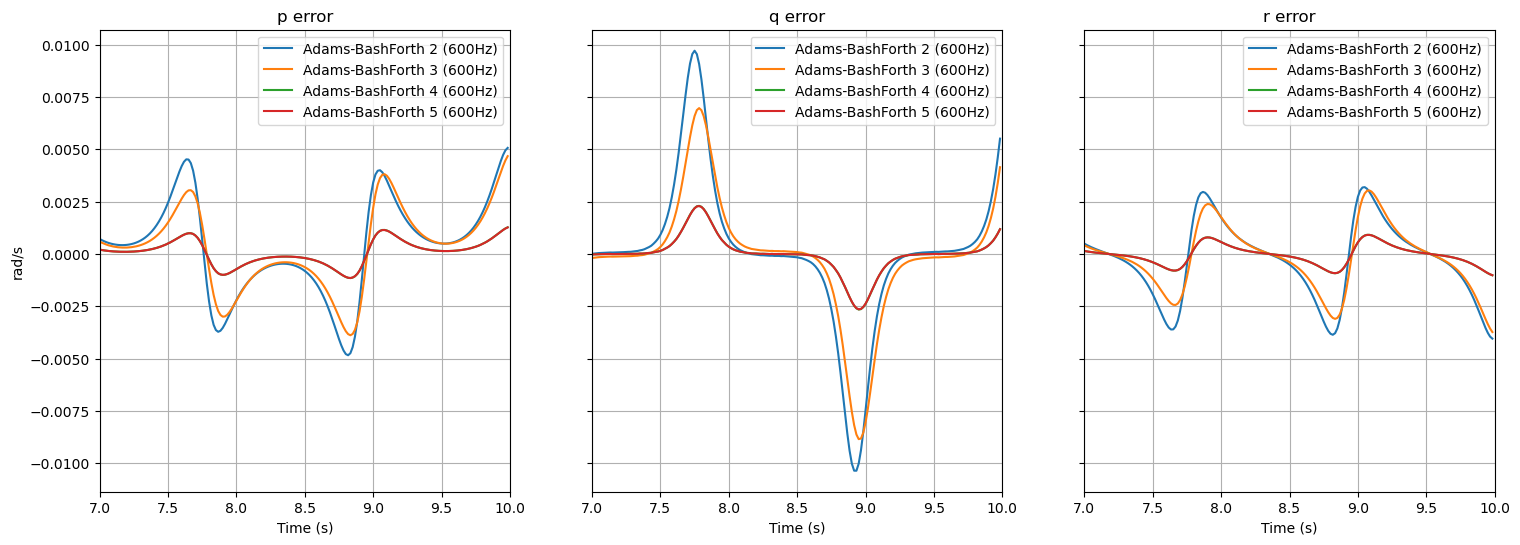

In [13]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH2, 600),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH3, 600),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH4, 600),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 600))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rate_errors(results, exact, time_range=(7, 10),name_col=1)

Below are plotted the error of the 5th order Adams-Bashforth scheme, halving the size of the time step at each simulation. As expected, the error converges to zero as the step size dimishes, confirming that JSBSim converges to the exact solution of the problem.

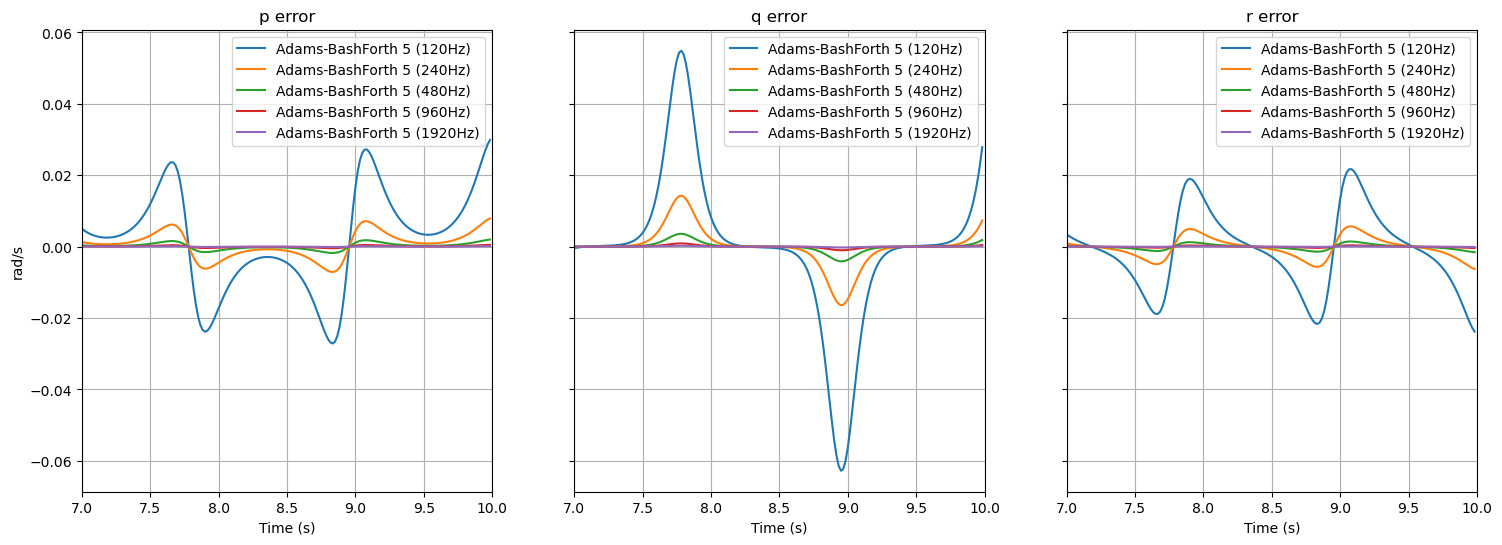

In [14]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 240),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 480),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 960),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 1920))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rate_errors(results, exact, time_range=(7,10),name_col=1)

## Euler Angles

In JSBSim, the computation of the aircraft attitude is done using quaternions which are notoriously much more stable than Euler angles:
* Quaternions are immune to the [Gimbal Lock problem](https://en.wikipedia.org/wiki/Gimbal_lock).
* Equations are much simpler in the quaternion space and only involve multiplications and additions, whereas the Euler angles rely on trigonometric functions which need more CPU power to be evaluated.

Euler angles are sort of a by-product of the quaternions in the JSBSim code and as such do not influence or alter the computation of the vehicle attitude.

On the down side, the components of quaternions do not relate easily to physical space, so for the continuation of this analysis, we will focus our investigation on the Euler angles to review the accuracy of JSBSim in computing the vehicle attitude.

Just as for the rotation rates, we will set up a couple of helper functions to display Euler angles and their error with respect to the exact solution.

### Helper functions for the tests

#### Plotting function for the Euler angles

This function displays the Euler angles (Roll, Pitch, Yaw) over time for the various integration methods.

The function parameters arethe same as `plot_rotation_rates`.

In [15]:
def plot_euler_angles(results: SimulationResults, exact_data, *, time_range=(0, t_final), name_col=0) -> None:
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

    for i in range(len(results.methods)):
        label = f"{method_names[results.methods[i][name_col]]} ({results.methods[i][2]:.0f}Hz)"
        ax1.plot(results.times[i, :], results.roll[i, :], label=label)
        ax2.plot(results.times[i, :], results.pitch[i, :], label=label)
        ax3.plot(results.times[i, :], results.yaw[i, :], label=label)

    ax1.plot(exact_data.iloc[:, 0], exact_data.iloc[:, 13], '+', label='Exact')
    ax2.plot(exact_data.iloc[:, 0], exact_data.iloc[:, 14], '+', label='Exact')
    ax3.plot(exact_data.iloc[:, 0], exact_data.iloc[:, 15], '+', label='Exact')

    ax1.set_ylabel("roll (rad)")
    ax2.set_ylabel("pitch (rad)")
    ax3.set_ylabel("yaw (rad)")
    ax3.set_xlabel("Time (s)")
    ax3.set_xlim(time_range)

    for ax in (ax1, ax2, ax3):
        ax.grid()
        ax.legend()

    plt.show()

#### Helper function for angle modulo

This utility function wraps angles into the $[-\pi, \pi]$ range to clean the apparent errors where an angle oscillates between 0 and $2\pi$.

In [16]:
def mod_2pi(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi

#### Plotting function for the Euler angle errors

This function computes and visualizes the errors in Euler angles, ensuring that angular wrap-around is properly handled.

The function parameters are the same as `plot_rotation_rates`.

In [17]:
def plot_euler_angle_errors(results: SimulationResults, exact_data, *, name_col=0) -> None:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    nvalues = len(exact_data)

    for i in range(len(results.methods)):
        step = int(results.methods[i][2] / freq_exact)
        label = f"{method_names[results.methods[i][name_col]]} ({results.methods[i][2]:.0f}Hz)"

        err_roll = mod_2pi(results.roll[i, :step*nvalues:step] - exact_data.iloc[:, 13])
        err_pitch = mod_2pi(results.pitch[i, :step*nvalues:step] - exact_data.iloc[:, 14])
        err_yaw = mod_2pi(results.yaw[i, :step*nvalues:step] - exact_data.iloc[:, 15])

        ax1.plot(exact_data.iloc[:, 0], err_roll, label=label)
        ax2.plot(exact_data.iloc[:, 0], err_pitch, label=label)
        ax3.plot(exact_data.iloc[:, 0], err_yaw, label=label)

    for ax, title in zip((ax1, ax2, ax3), ("roll error", "pitch error", "yaw error")):
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.legend()
        ax.grid()

    ax1.set_ylabel("rad")
    plt.show()

### Adams-Bashforth methods

In JSBSim, the quaternion rate is computed from the rotation rate with the following differential equation:

$$\dot{q}=\dfrac{1}{2}q\times\omega$$

Hence the accuracy of the vehicle attitude depends directly on the accuracy of $\omega$ i.e. of $(p, q, r)$. For that reason, we will not investigate the Euler and trapezoidal schemes for the computation of Euler angles and the Adams-Bashforth scheme of the 5th order will be used to compute the rotation rates with maximum accuracy.

It is to be noted that quaternions that are used to compute the vehicle attitude are unit quaternions i.e. $||q||=1$. However the Adams-Bahsforth schemes do not preserve the quaternion norm:

$$q(t+h)=q(t)+\dfrac{h}{2}(3\dot{q}(t)-\dot{q}(t-h))$$

So JSBSim normalizes the quaternion after each time step to improve the integration scheme stability.

Below are displayed the computation of the Euler angles for the Adams-Bashforth schemes on the last 2 seconds of the simulation. The "spike" of the Adams-Bashforth method of the 5th order around t=8.8s for the roll angle is due to the angle modulo between $-\pi$ and $\pi$. The actual error is much smaller than it seems by inspecting the plot

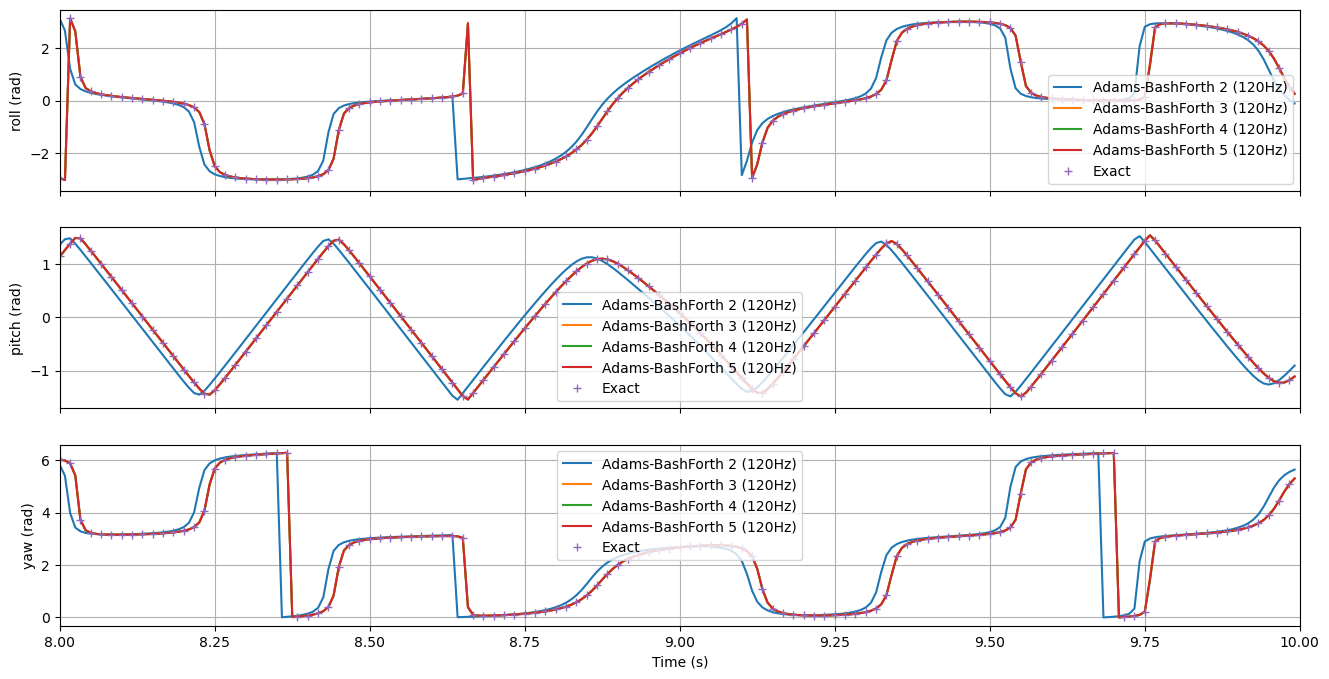

In [18]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH2, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH3, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH4, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angles(results, exact, time_range=(8,10))

The 2nd order Adams-Bashforth scheme is performing notably worse than the other Adams-Bashforth schemes and from now on, we will only focus on the Adams-Bashforth schemes of the 3rd, 4th and 5th order.

Below are the error of these schemes with respect to the exact solution. It is to be noted that the relative error for the 3 schemes is of the order of $\frac{0.01}{\pi}\approx 3.10^{-3}$ which is not particularly good.

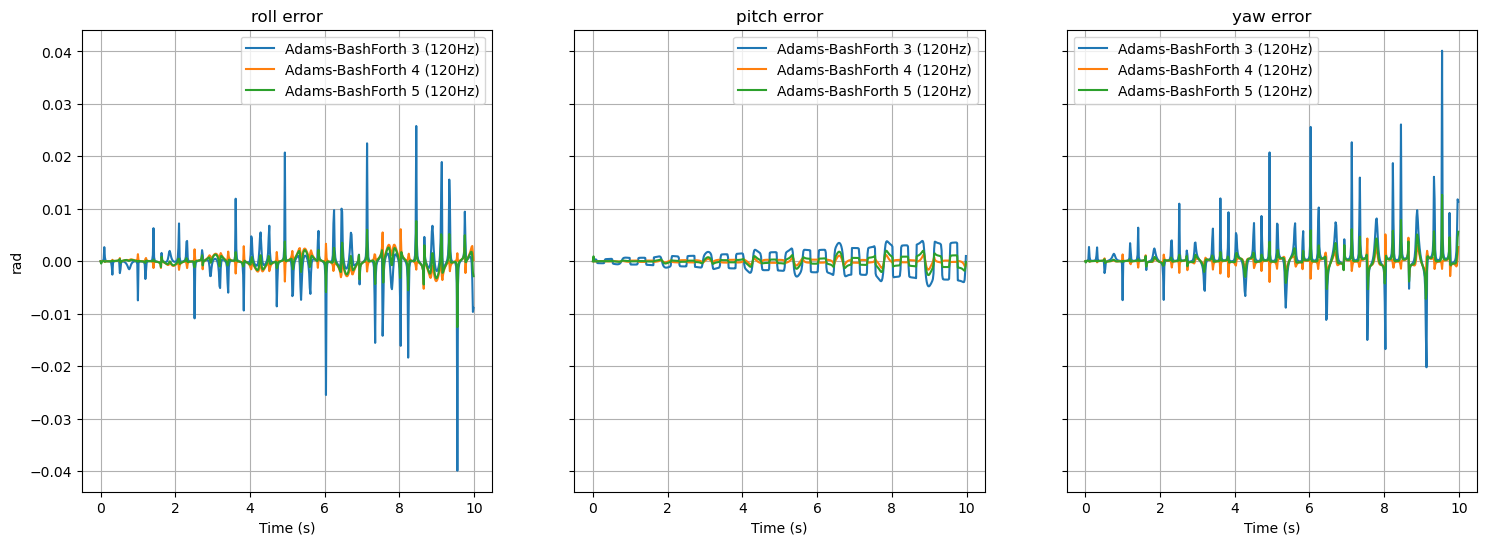

In [19]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH3, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH4, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

### Methods specifically designed for quaternions

From a mathematical point of view, Adams-Bashforth is not well-suited to solve the quaternion ODE for vehicle attitude. Indeed, as explained previously, the Adams-Bashforth schemes do not preserve the quaternion norm. For better accuracy, an integration scheme for rigid body rotation should only use mathematical operations that preserve the quaternion norm such as the multiplication and the exponentiation. An extensive amount of scientific litterature is devoted to this subject

JSBSim includes some of these methods specifically designed for the integration of quaternions ODE:
- Methods of the first and second order from Samuel Buss' paper *Accurate and Efficient Simulation of Rigid Body Rotations*, Buss S., 2001
- Local linearization from the NASA technical note TN D-7347 *Development and Application of a Local Linearization Algorithm for the Integration of Quaternion Rate Equations in Real-Time Flight Simulation Problems*, Barker E. Jr, Bowles R., Williams L, 1973

We will now focus on comparing these "quaternion methods" to Adams-Bashforth and see how they perform.

Theoretically Buss methods are of the first and second order and local linearization from Barker et al. is lower than the second order. So we will start by comparing the Buss scheme of the first order and the local linearization to Adams-Bashforth scheme of the 2nd order.

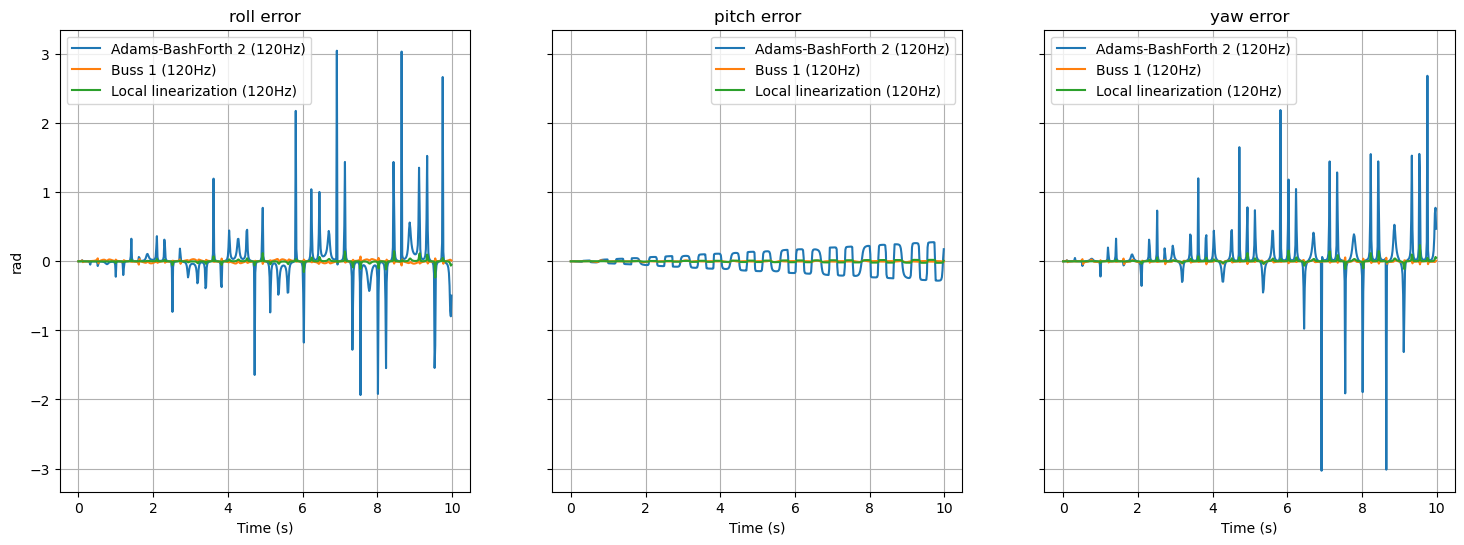

In [20]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH2, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.BUSS1, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.LOCAL_LINEARIZATION, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

The Buss scheme of the first order and Barker's local linearization perform much better than Adams-Bashforth of the 2nd order. This is confirming that methods specifically designed for quaternions ODE are much more accurate at comparable order. There results are also in line with the tests conducted in Barker et al.'s paper.

We will now compare Buss 1 and local linearization to the Adams-Bashforth scheme of the 3rd order.

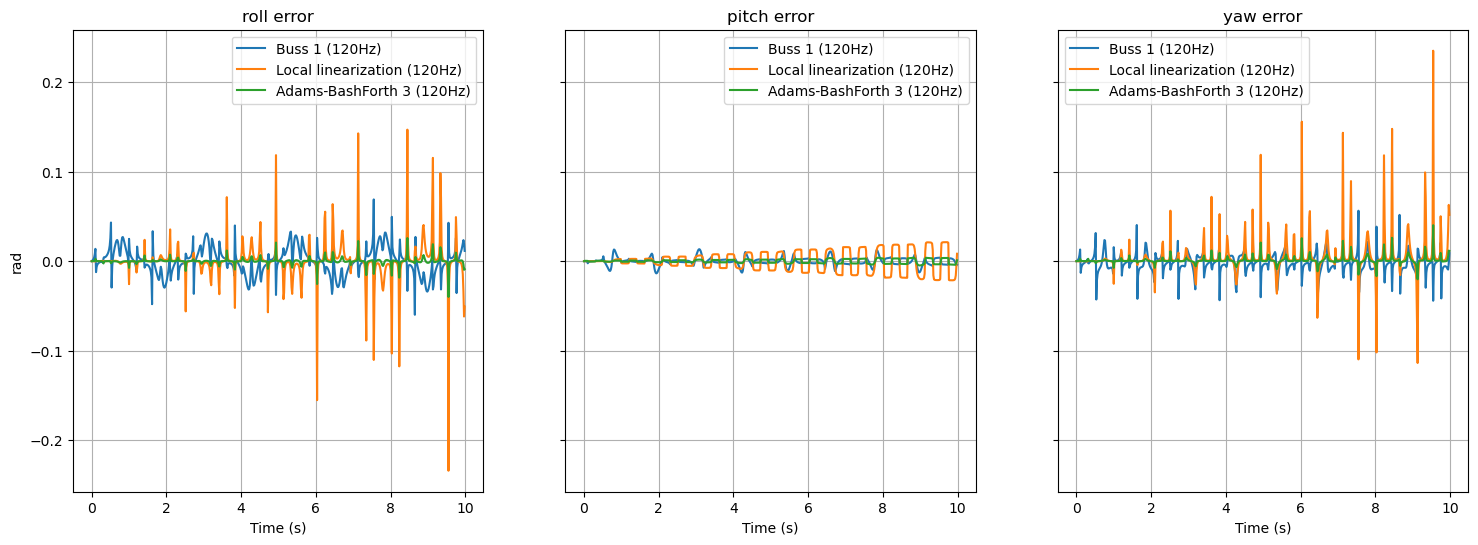

In [21]:
integrators =  ((ODE_methods.BUSS1, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.LOCAL_LINEARIZATION, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH3, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

Both the Buss scheme of the first order and local linearization are performing worse than Adams-Bashforth of the 3rd order with Buss performing measurably better than local linearization.

It is remarkable that a first order method such as Buss' has an accuracy comprised between Adams-Bahsforth 2 and 3, being much closer to Adams-Bashforth 3 than to Adams-Bashforth 2.

Let's now see how the Buss scheme of the 2nd order performs with respect to the Adams-Bashforth scheme of the 3rd order.

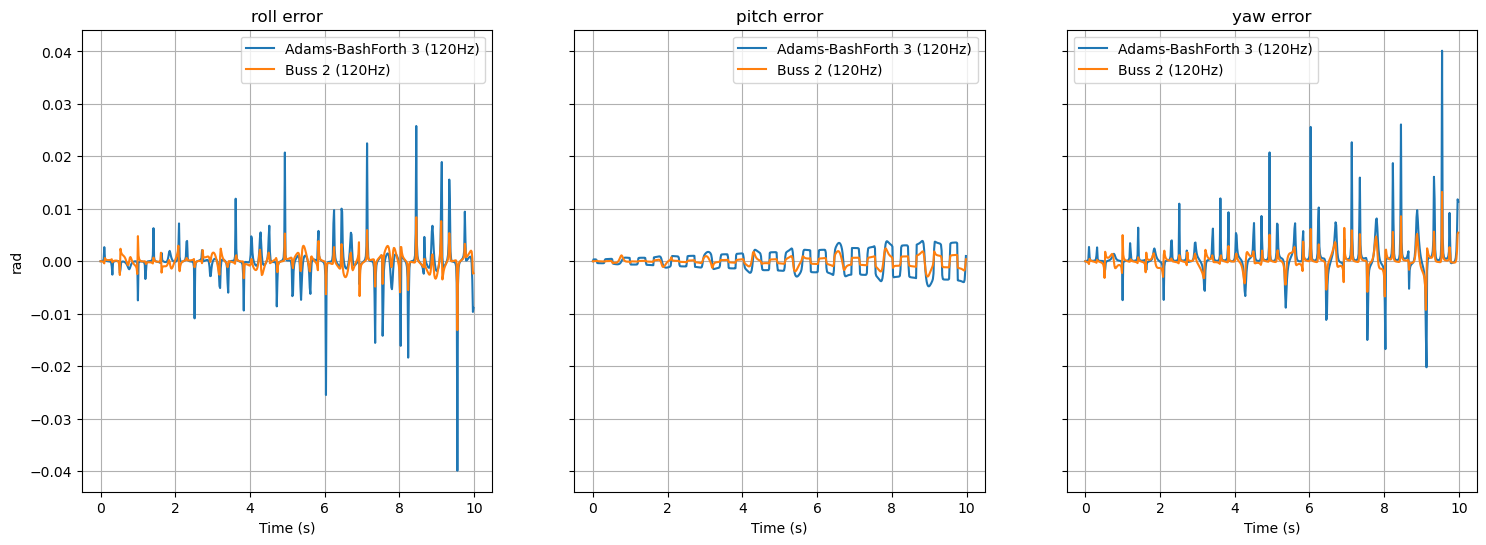

In [22]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH3, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.BUSS2, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

The Buss scheme of the second order is more accurate than Adams-Bashforth 3, confirming once again that for a given order, methods specifically designed for the quaternion ODE perform much better than general methods such as Adams-Bashforth.

Comparing Buss 2 with Adams-Bashforth of the 4th and 5th order confirm that statement: the 3 methods have similar accuracy with Adams-Bashforth 4 and 5 being slightly better than Buss 2. It is a remarkable achievemnt for a second order method to perform in the same precision range as general methods of the 4th and 5th order.

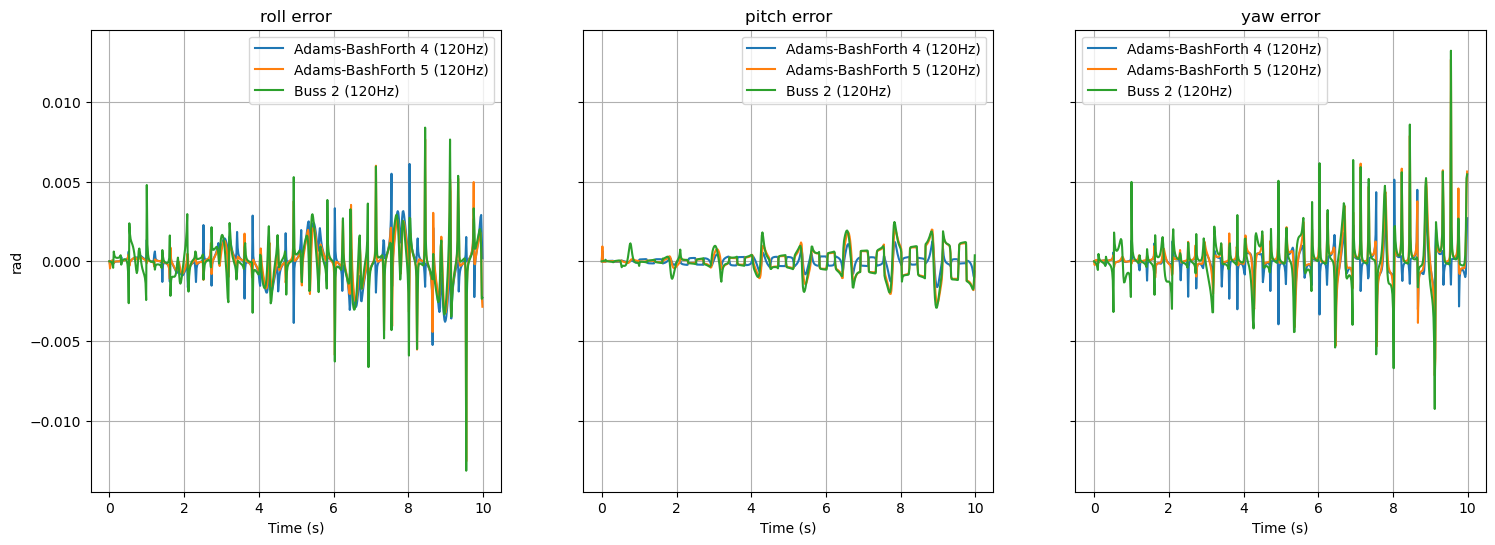

In [23]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH4, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.BUSS2, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)